<a href="https://colab.research.google.com/github/MystxcHD/MNIST-NN-Project/blob/main/MNIST_Neural_Network_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/NN_AND_ML/mnist_train.csv")

In [ ]:
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = np.array(data)
m, n = data.shape # m is the number of rows and n is the number of features + 1
np.random.shuffle(data)

In [ ]:
print(m, n)

60000 785


In [ ]:
train_data = data[0:1000].T # 80% of the set is the training data
val_data = data[1000:m].T # Validation data (testing)

In [ ]:
Y_train = train_data[0]
X_train = train_data[1:n] / 255.0

Y_val = val_data[0]
X_val = val_data[1:n] / 255.0

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Now we will start with the NN (this is the setup for the NN)

def init_params():
  W1 = np.random.rand(10, 784) - 0.5
  B1 = np.random.rand(10, 1) - 0.5
  W2 = np.random.rand(10, 10) - 0.5
  B2 = np.random.rand(10, 1) - 0.5

  return W1, B1, W2, B2

def ReLU(Z):
  return np.maximum(0, Z)

def softmax(Z):
  return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)

def forward_propagation(W1, B1, W2, B2, X):
  Z1 = W1.dot(X) + B1
  A1 = ReLU(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax(Z2)

  return Z1, A1, Z2, A2

def one_hot(Y):
  one_hot_Y = np.zeros((Y.max() + 1, Y.size))
  one_hot_Y[Y, np.arange(Y.size)] = 1

  return one_hot_Y

def deriv_ReLU(Z):
  return Z > 0

def backward_propagation(Z1, A1, Z2, A2, W2, X, Y):
  m = Y.size
  one_hot_Y = one_hot(Y)
  dZ2 = A2 - one_hot_Y
  dW2 = (1 / m) * dZ2.dot(A1.T)
  dB2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True) # Corrected axis and keepdims
  dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
  dW1 = (1 / m) * dZ1.dot(X.T) # Changed from dZ2 to dZ1
  dB1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True) # Corrected axis and keepdims

  return dW1, dB1, dW2, dB2

def update_params(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha):
  W1 = W1 - alpha * dW1
  B1 = B1 - alpha * dB1
  W2 = W2 - alpha * dW2
  B2 = B2 - alpha * dB2

  return W1, B1, W2, B2

In [ ]:
# This is the code for the NN (gradient descent)

def get_predictions(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):

  return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
  W1, B1, W2, B2 = init_params()
  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_propagation(W1, B1, W2, B2, X)
    dW1, dB1, dW2, dB2 = backward_propagation(Z1, A1, Z2, A2, W2, X, Y)
    W1, B1, W2, B2 = update_params(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha)
    if (i % 50 == 0):
      print(f"Iteration: {i}")
      print(f"Accuracy: {get_accuracy(get_predictions(A2), Y)}")
  return W1, B1, W2, B2

In [ ]:
W1, B1, W2, B2 = gradient_descent(X_train, Y_train, 500, 0.5)

Iteration: 0
Accuracy: 0.087
Iteration: 50
Accuracy: 0.659
Iteration: 100
Accuracy: 0.887
Iteration: 150
Accuracy: 0.925
Iteration: 200
Accuracy: 0.952
Iteration: 250
Accuracy: 0.966
Iteration: 300
Accuracy: 0.978
Iteration: 350
Accuracy: 0.987
Iteration: 400
Accuracy: 0.991
Iteration: 450
Accuracy: 0.993


In [ ]:
# Testing functions

# Run a single image through the network
def make_prediction(X, W1, B1, W2, B2):
    _, _, _, A2 = forward_propagation(W1, B1, W2, B2, X)
    predictions = get_predictions(A2)
    return predictions

# Grab the single image and its true label based on the index
def test_prediction(index, W1, B1, W2, B2):
    current_image = X_train[:, index, None]
    prediction = make_prediction(current_image, W1, B1, W2, B2)
    label = Y_train[index]

    print(f"Prediction: {prediction[0]}")
    print(f"True Label: {label}")

    current_image_reshaped = current_image.reshape((28, 28))

    # Plot the image in grayscale
    plt.gray()
    plt.imshow(current_image_reshaped, interpolation='nearest')
    plt.axis('off')
    plt.show()

Prediction: 6
True Label: 6


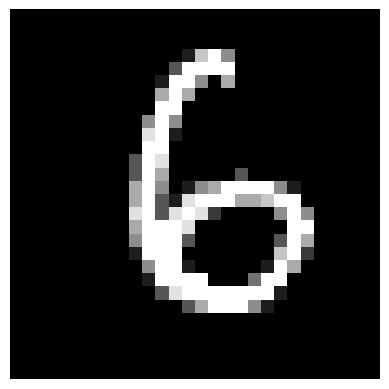

In [ ]:
# Test the first image in your dataset
test_prediction(90, W1, B1, W2, B2)